# Exploratory Data Analysis (EDA)

This notebook explores the processed heart disease dataset and saves all generated plots into the `notebooks/eda_images` folder.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
# Set a clean plotting style so charts are easier to read.
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

In [3]:
def find_project_root(start_path: Path) -> Path:
    current = start_path.resolve()

    for path in [current, *current.parents]:
        # Use the data folder to identify the main project directory.
        if (path / 'data').exists():
            return path

    raise FileNotFoundError('Project root not found.')



In [4]:

# Define the main project paths used in this notebook.
BASE_DIR = find_project_root(Path.cwd())
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'heart_disease_processed.csv'
IMAGE_DIR = BASE_DIR / 'notebooks' / 'eda_images'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR, DATA_PATH, IMAGE_DIR

(WindowsPath('D:/PROJECT OF DATA SCIENCE/Heart Disease Health Indicators'),
 WindowsPath('D:/PROJECT OF DATA SCIENCE/Heart Disease Health Indicators/data/processed/heart_disease_processed.csv'),
 WindowsPath('D:/PROJECT OF DATA SCIENCE/Heart Disease Health Indicators/notebooks/eda_images'))

In [5]:
# Load the processed dataset and keep a separate working copy for analysis.
data = pd.read_csv(DATA_PATH)
df = data.copy()
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0.0,0,0,...,1,0,5.0,18.0,15.0,1,0,9.0,4.0,3.0
1,0,0,0,0,25.0,1,0,0.0,1,0,...,0,1,3.0,0.0,0.0,0,0,7.0,6.0,1.0
2,0,1,1,1,28.0,0,0,0.0,0,1,...,1,1,5.0,30.0,30.0,1,0,9.0,4.0,8.0
3,0,1,0,1,27.0,0,0,0.0,1,1,...,1,0,2.0,0.0,0.0,0,0,11.0,3.0,6.0
4,0,1,1,1,24.0,0,0,0.0,1,1,...,1,0,2.0,3.0,0.0,0,0,11.0,5.0,4.0


In [6]:
# Check the shape of the dataset and inspect data types.
print(f'Dataset shape: {df.shape}')
print('\nColumn data types:')
print(df.dtypes)

Dataset shape: (229781, 22)

Column data types:
HeartDiseaseorAttack      int64
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
Diabetes                float64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost               int64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [7]:
# Check whether any missing values are still present after preprocessing.
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
# Display summary statistics for all numeric columns.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,229781.0,0.103216,0.304241,0.0,0.0,0.0,0.0,1.0
HighBP,229781.0,0.454441,0.497921,0.0,0.0,0.0,1.0,1.0
HighChol,229781.0,0.441760,0.496598,0.0,0.0,0.0,1.0,1.0
CholCheck,229781.0,0.959535,0.197047,0.0,1.0,1.0,1.0,1.0
BMI,229781.0,28.685670,6.786360,12.0,24.0,27.0,32.0,98.0
Smoker,229781.0,0.465661,0.498821,0.0,0.0,0.0,1.0,1.0
Stroke,229781.0,0.044756,0.206767,0.0,0.0,0.0,0.0,1.0
Diabetes,229781.0,0.325627,0.724623,0.0,0.0,0.0,0.0,2.0
PhysActivity,229781.0,0.733355,0.442206,0.0,0.0,1.0,1.0,1.0
Fruits,229781.0,0.612966,0.487073,0.0,0.0,1.0,1.0,1.0


In [9]:
# Analyze the target variable to understand class balance.
target_column = 'HeartDiseaseorAttack'

target_counts = df[target_column].value_counts().sort_index()
target_percentages = df[target_column].value_counts(normalize=True).sort_index() * 100

print('Target class counts:')
print(target_counts)
print('\nTarget class percentages:')
print(target_percentages.round(2))

Target class counts:
HeartDiseaseorAttack
0    206064
1     23717
Name: count, dtype: int64

Target class percentages:
HeartDiseaseorAttack
0    89.68
1    10.32
Name: proportion, dtype: float64


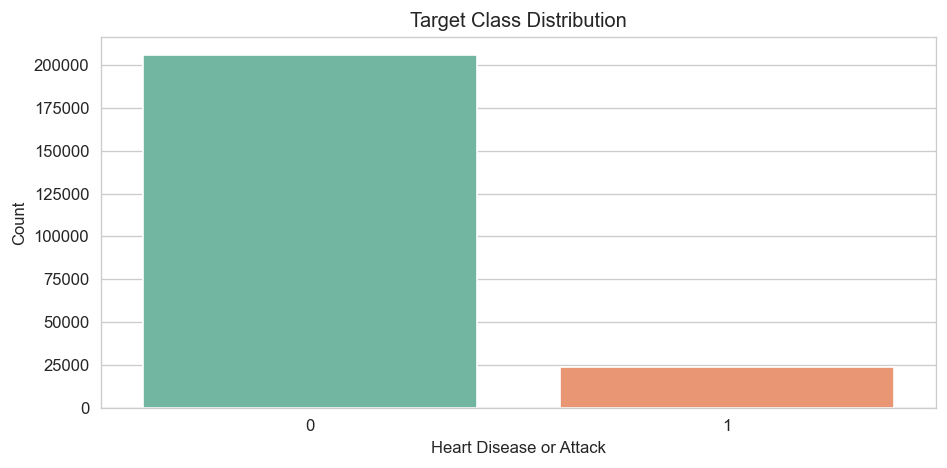

In [10]:
# Plot the target distribution and save the chart for later reference.
FIGURE_SIZE = (8, 4)
plt.figure(figsize=FIGURE_SIZE)
sns.countplot(data=df, x=target_column, hue=target_column, palette='Set2', legend=False)
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease or Attack')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'target_class_distribution.png', bbox_inches='tight')
plt.show()

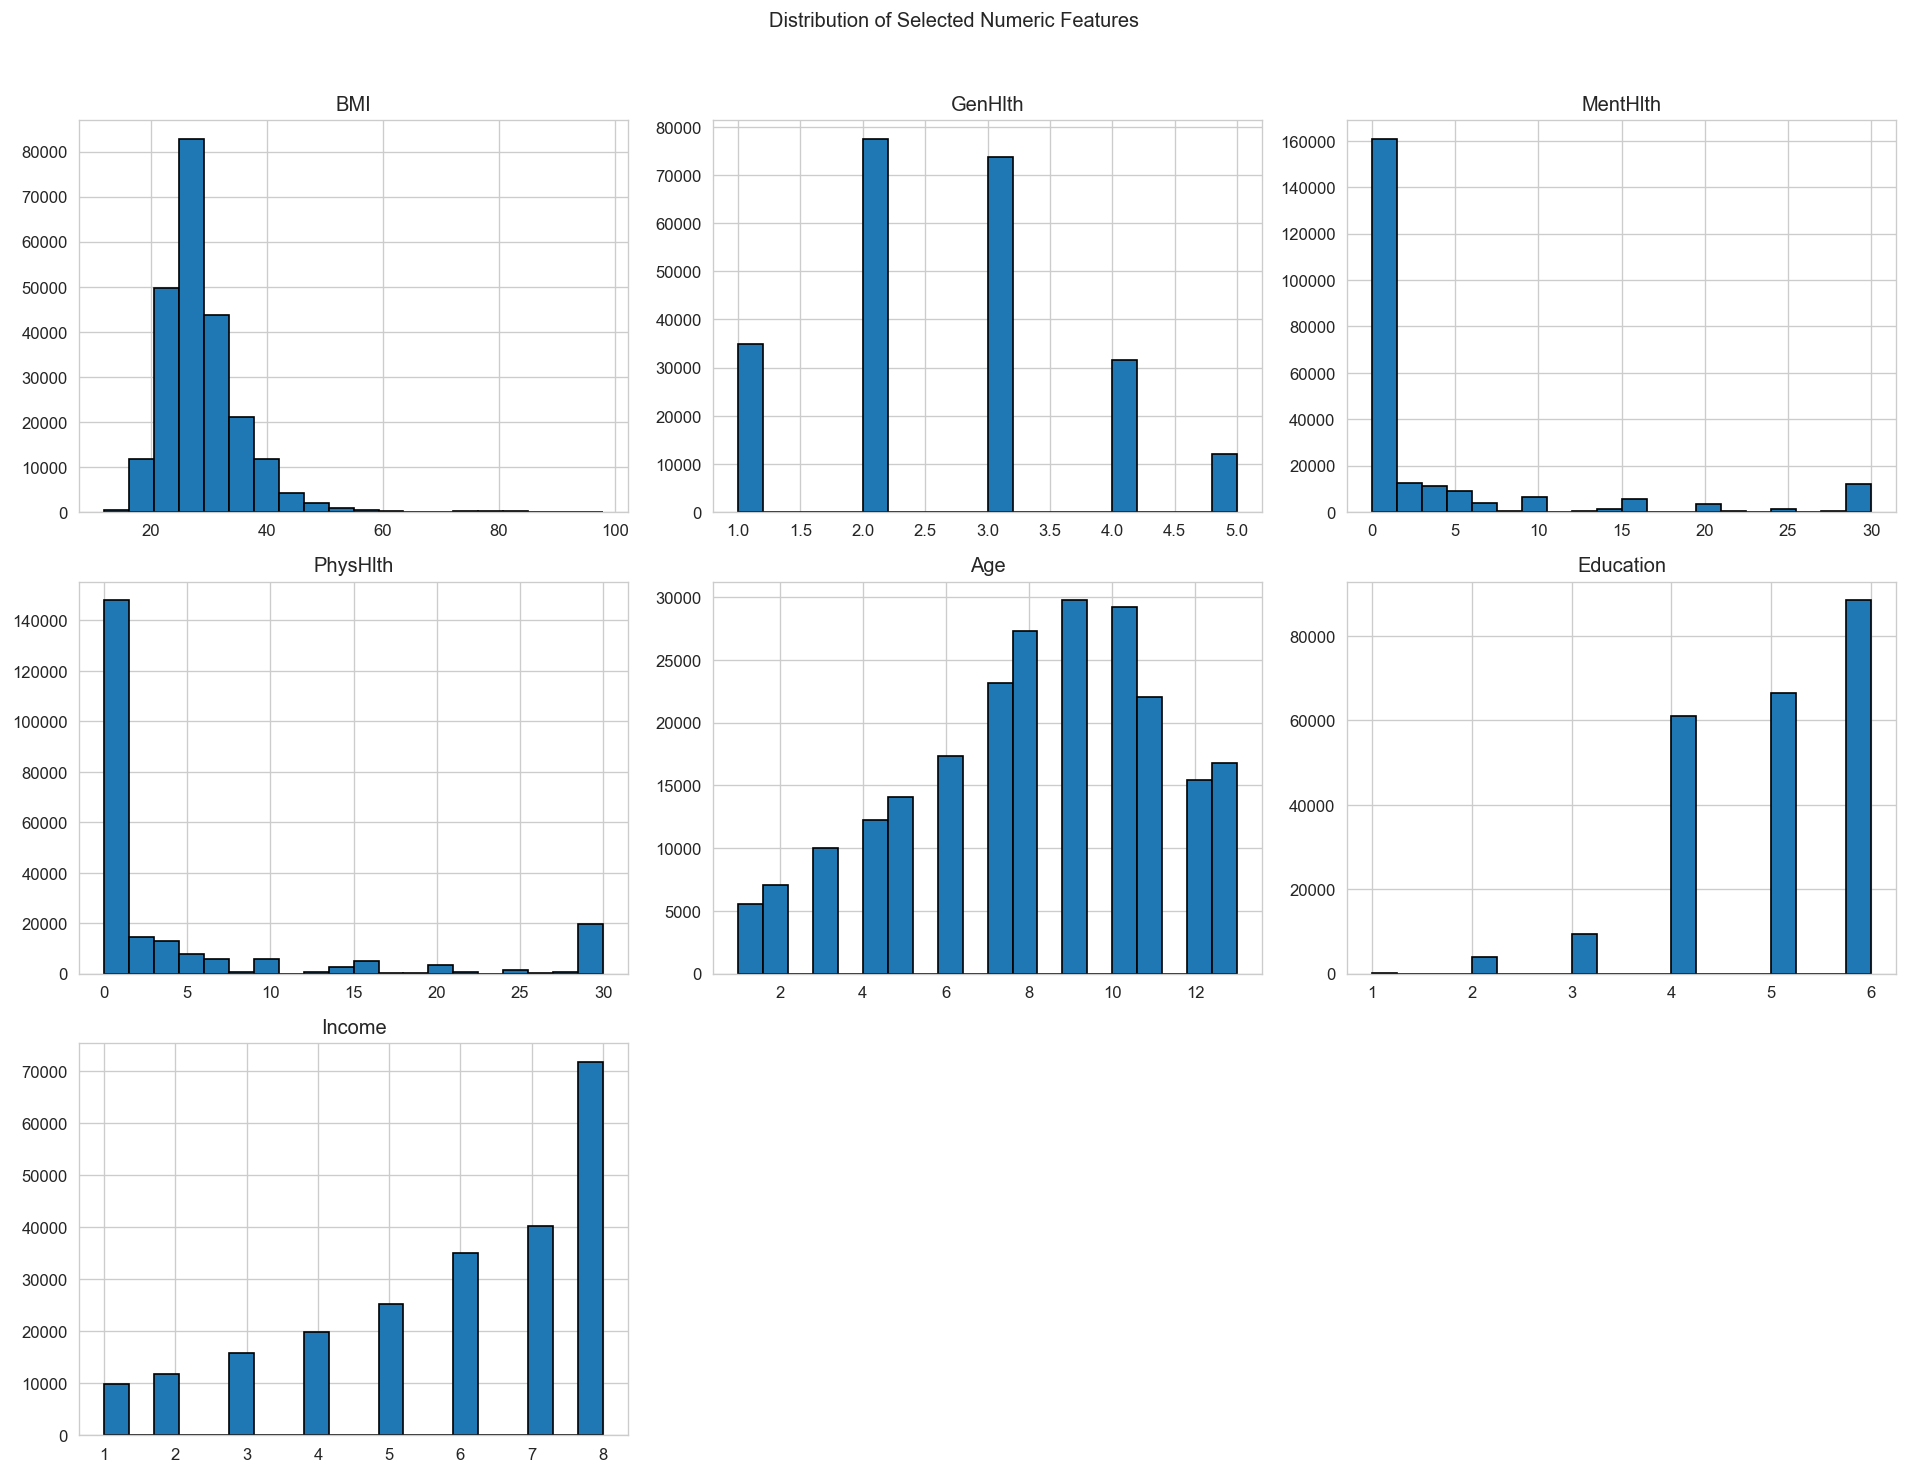

In [11]:
# Plot important numeric columns to understand their distributions.
numeric_columns_to_plot = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
numeric_columns_to_plot = [col for col in numeric_columns_to_plot if col in df.columns]

df[numeric_columns_to_plot].hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle('Distribution of Selected Numeric Features', y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'numeric_feature_distributions.png', bbox_inches='tight')
plt.show()

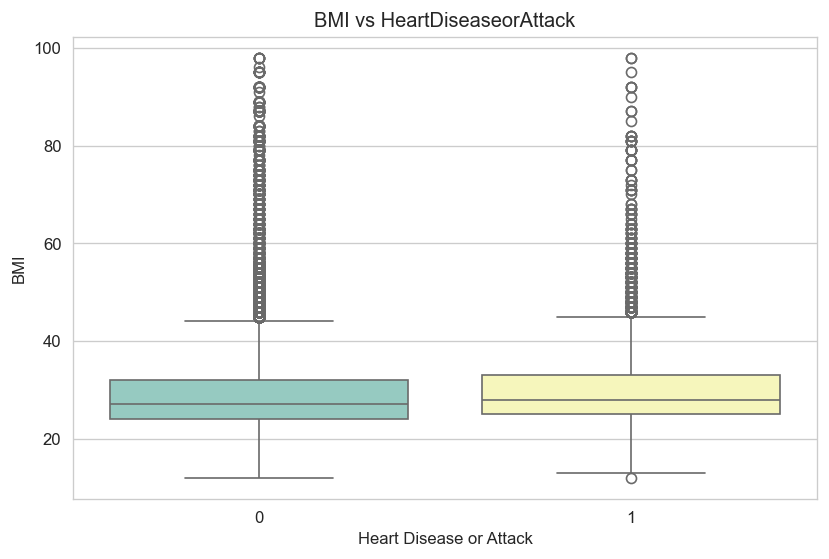

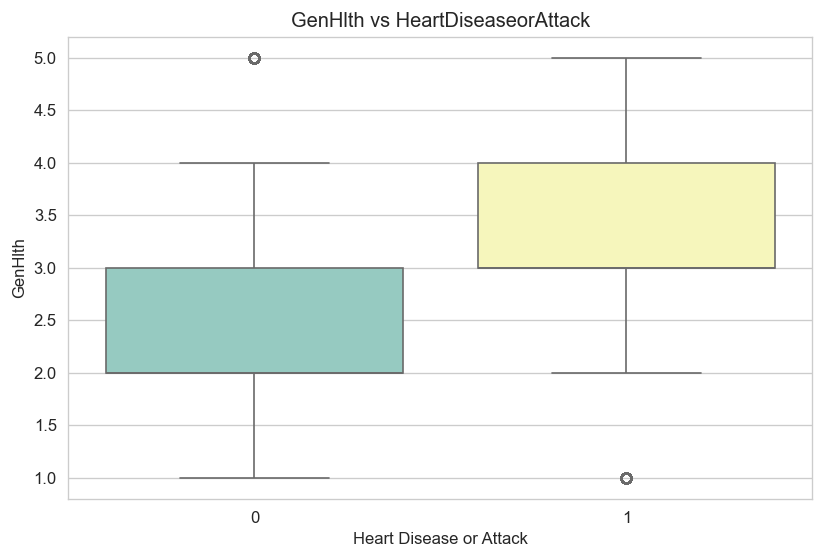

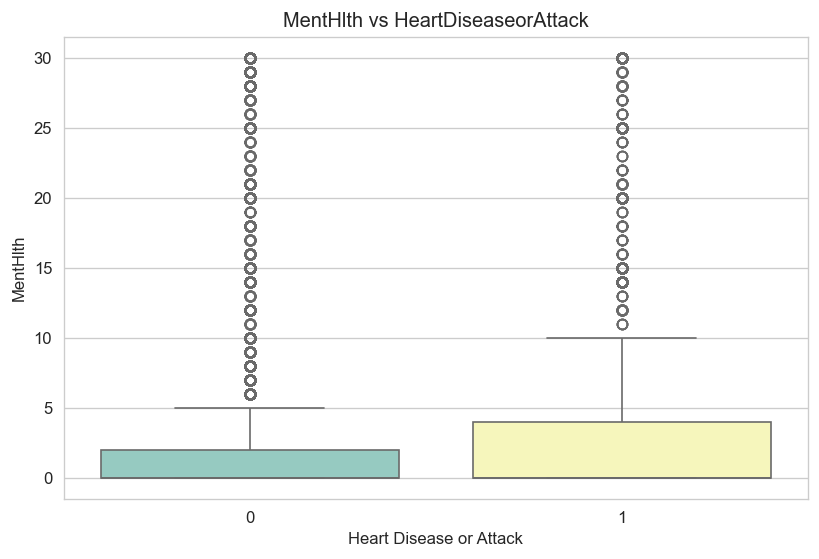

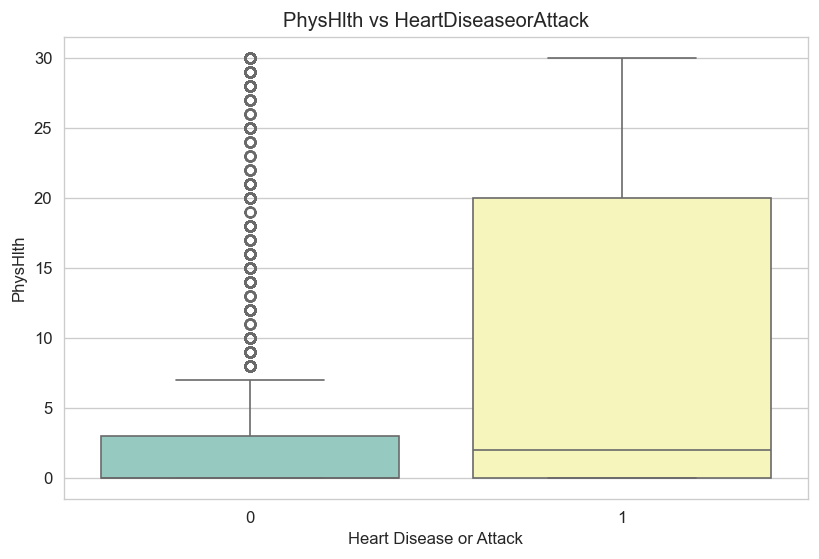

In [12]:
# Compare numeric feature distributions against the target class.
features_for_boxplot = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth']
features_for_boxplot = [col for col in features_for_boxplot if col in df.columns]

for column in features_for_boxplot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=target_column, y=column, palette='Set3')
    plt.title(f'{column} vs {target_column}')
    plt.xlabel('Heart Disease or Attack')
    plt.ylabel(column)
    plt.show()

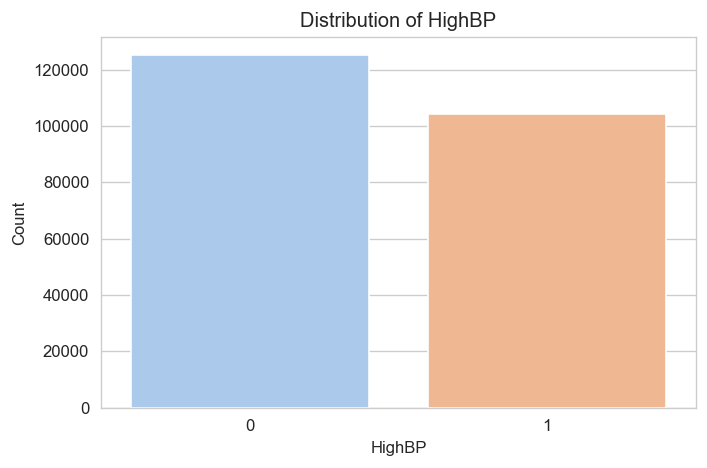

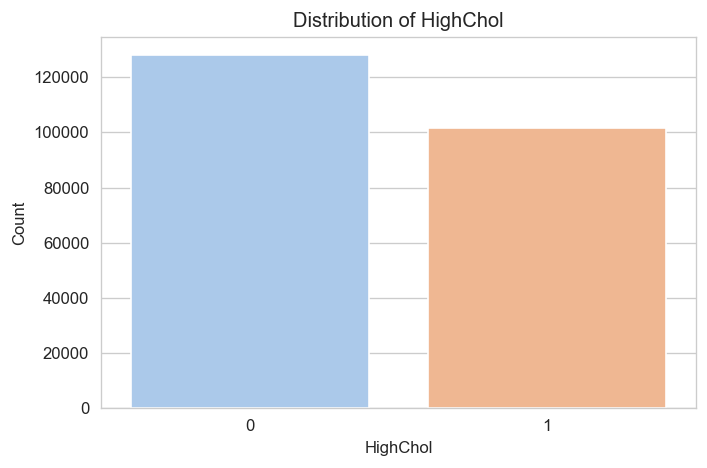

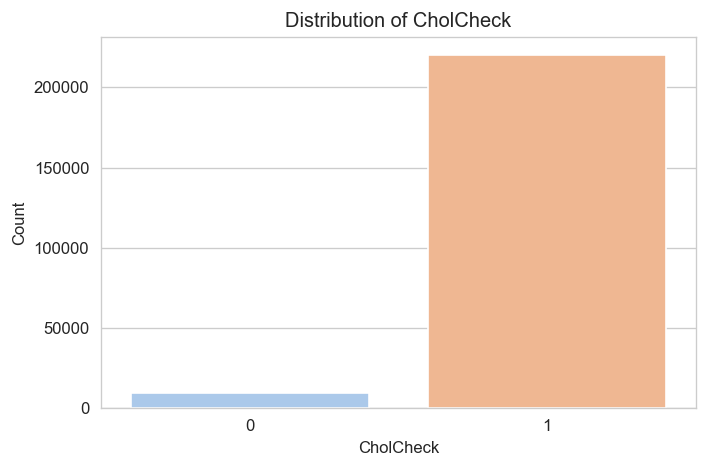

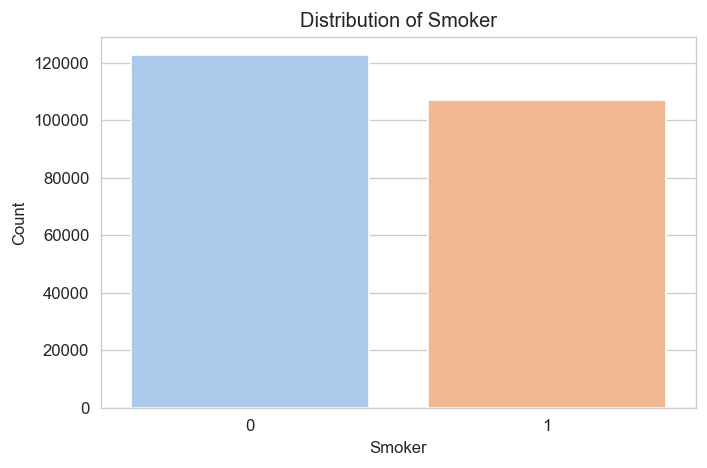

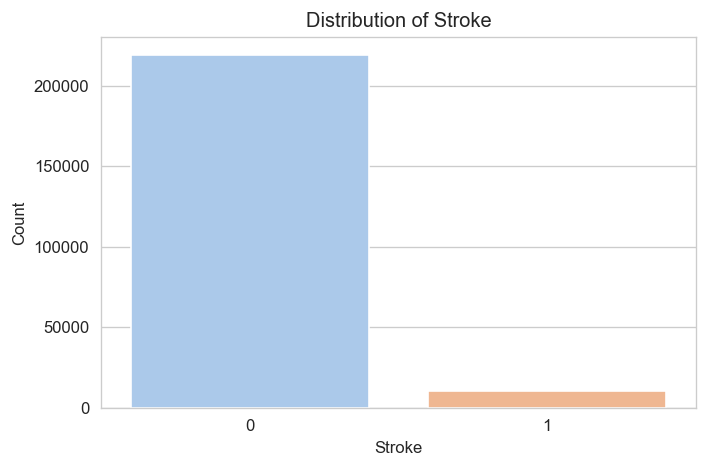

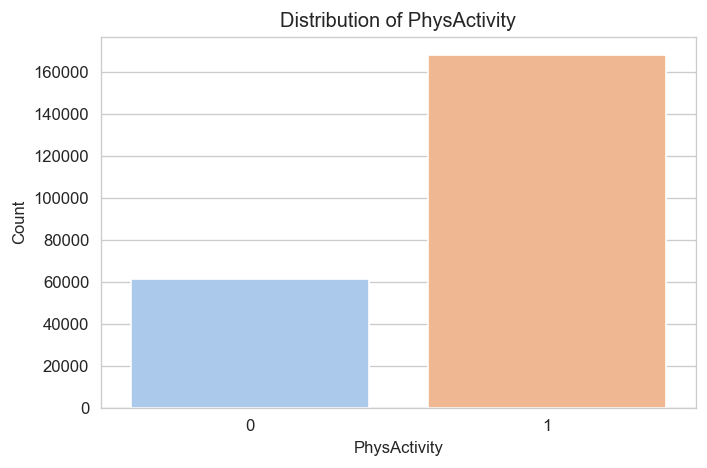

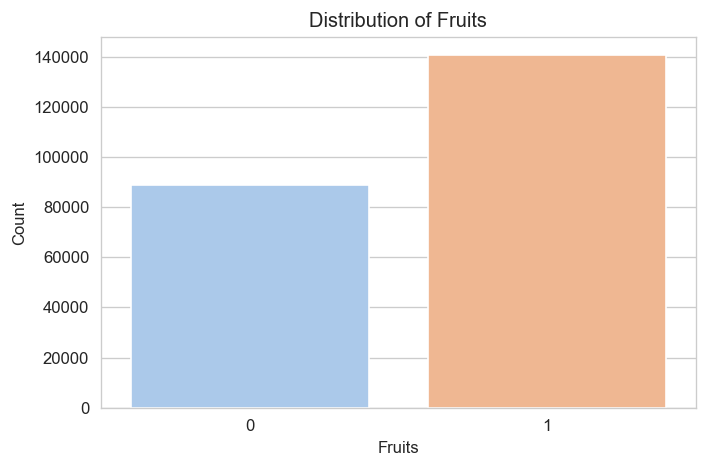

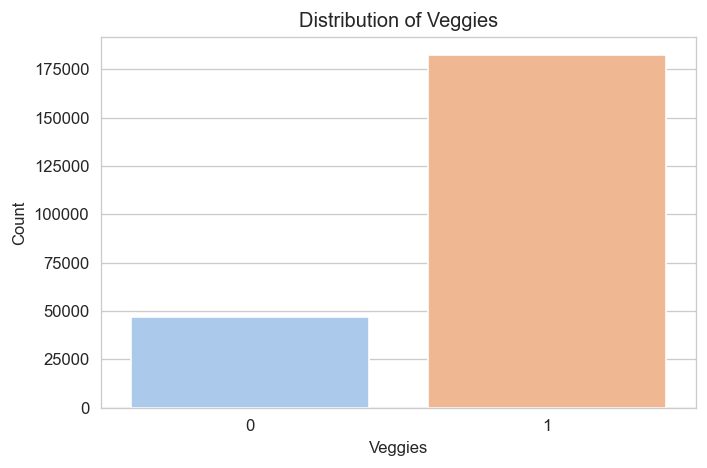

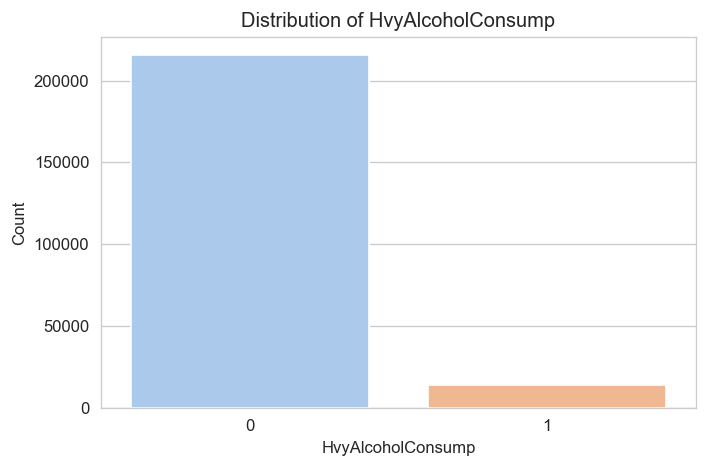

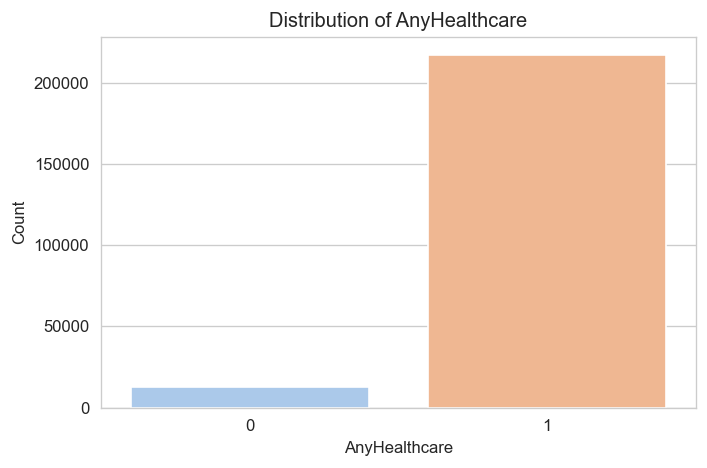

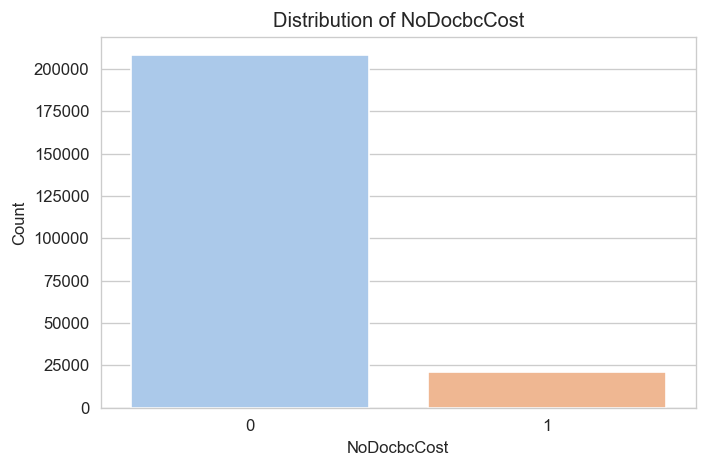

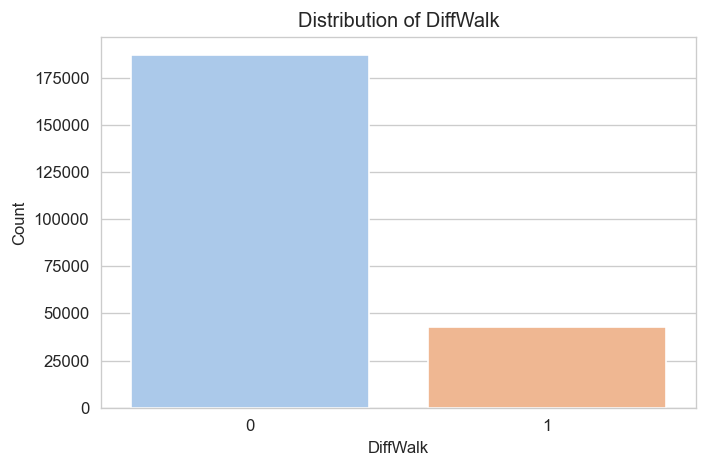

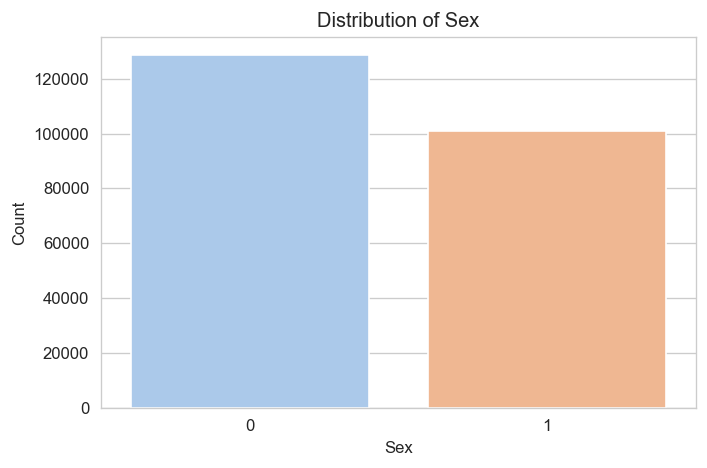

In [13]:
# Review how binary health indicators are distributed.
binary_columns = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]
binary_columns = [col for col in binary_columns if col in df.columns]

for column in binary_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=column, hue=column, palette='pastel', legend=False)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f'binary_distribution_{column.lower()}.png', bbox_inches='tight')
    plt.show()

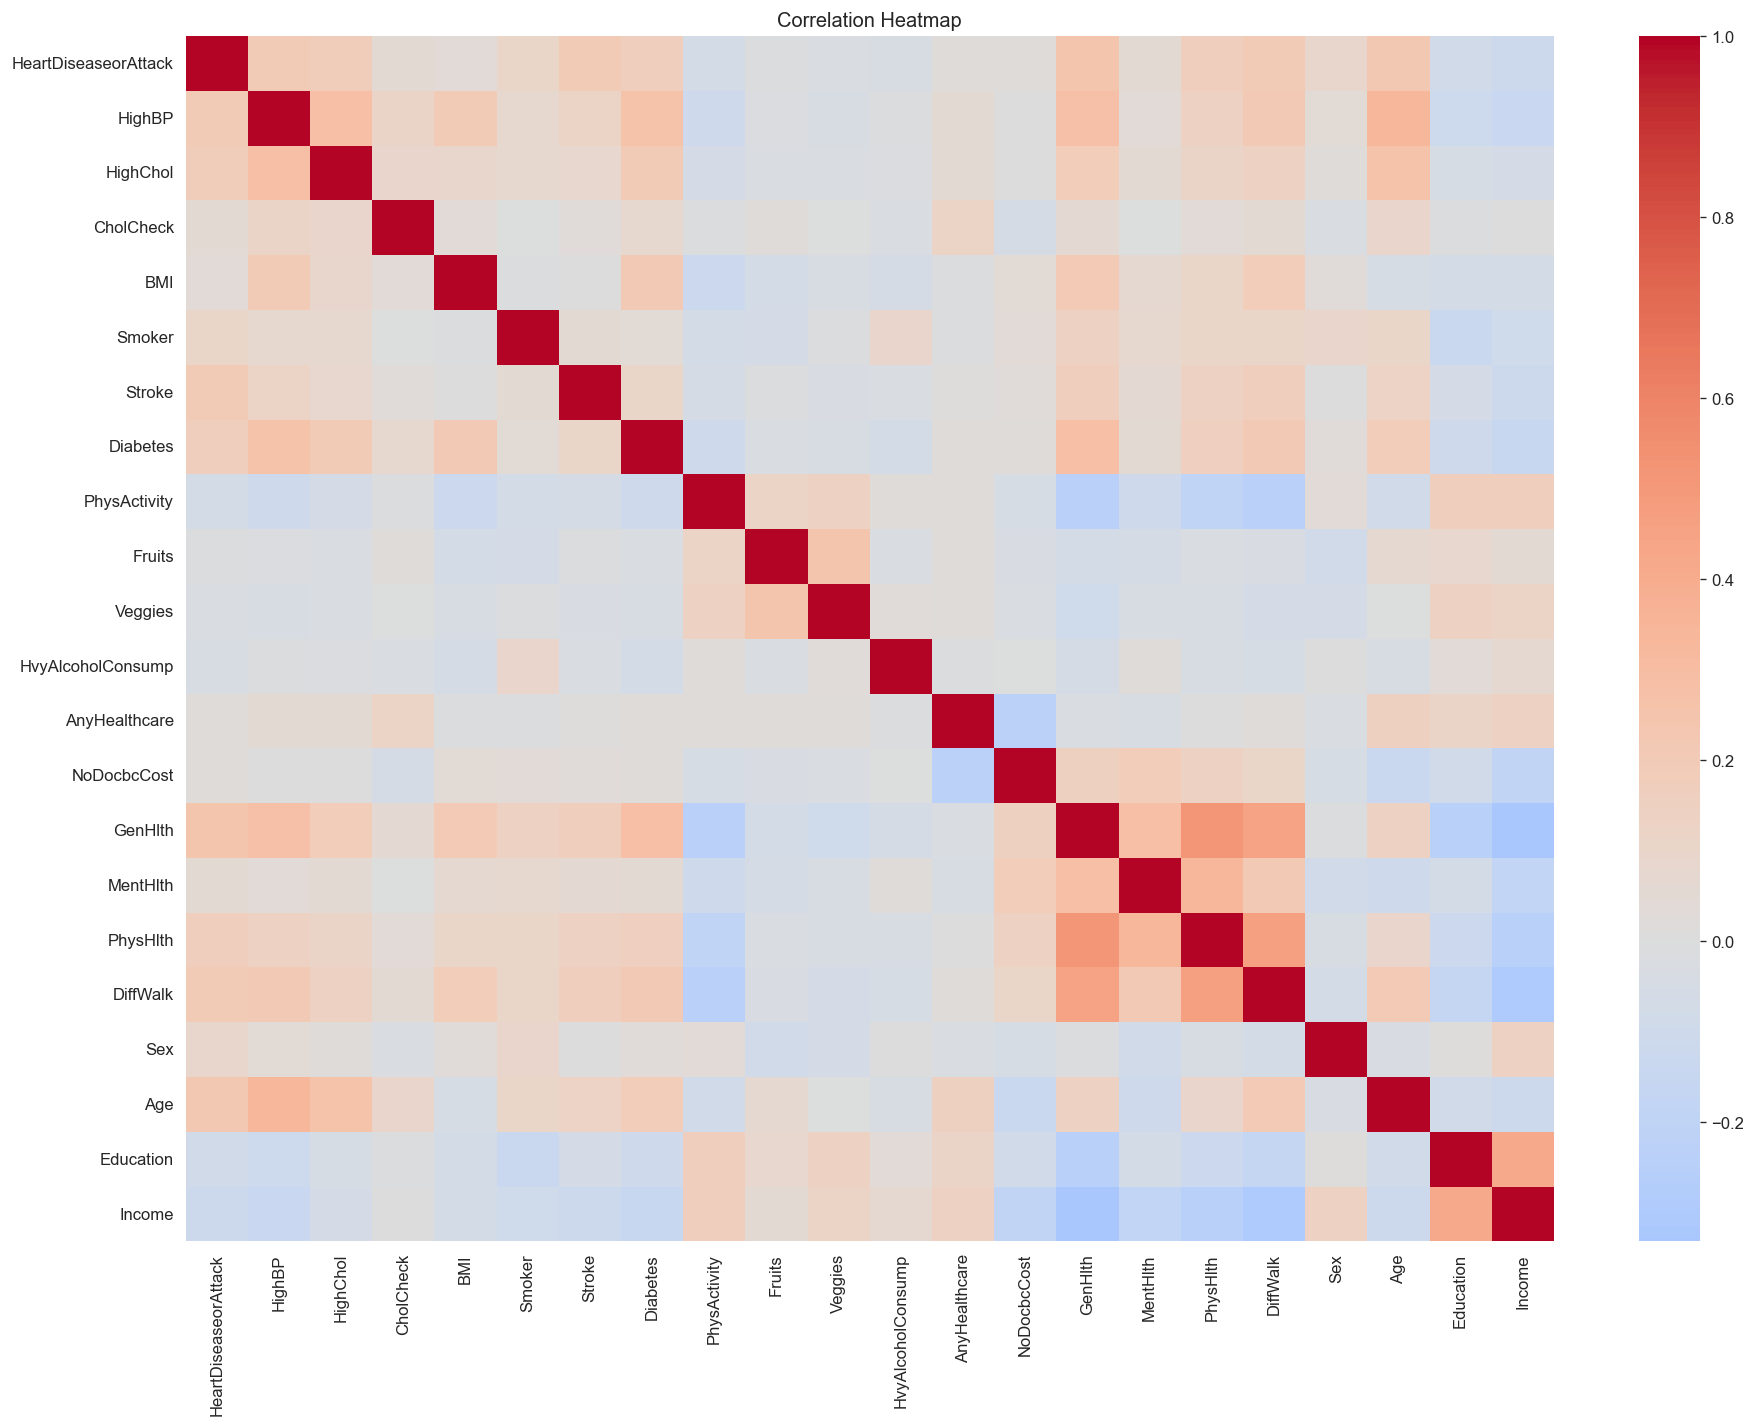

In [14]:
# Measure linear relationships between numeric columns with a correlation heatmap.
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [15]:
# Show the features most correlated with the target variable.
target_correlation = correlation_matrix[target_column].sort_values(ascending=False)
target_correlation

HeartDiseaseorAttack    1.000000
GenHlth                 0.246411
Age                     0.223626
DiffWalk                0.202779
HighBP                  0.201271
Stroke                  0.198863
HighChol                0.176279
Diabetes                0.170816
PhysHlth                0.170473
Smoker                  0.105154
Sex                     0.089717
MentHlth                0.052756
CholCheck               0.049995
BMI                     0.039926
AnyHealthcare           0.025899
NoDocbcCost             0.022076
Fruits                 -0.007128
Veggies                -0.027330
HvyAlcoholConsump      -0.035453
PhysActivity           -0.073267
Education              -0.082466
Income                 -0.122908
Name: HeartDiseaseorAttack, dtype: float64

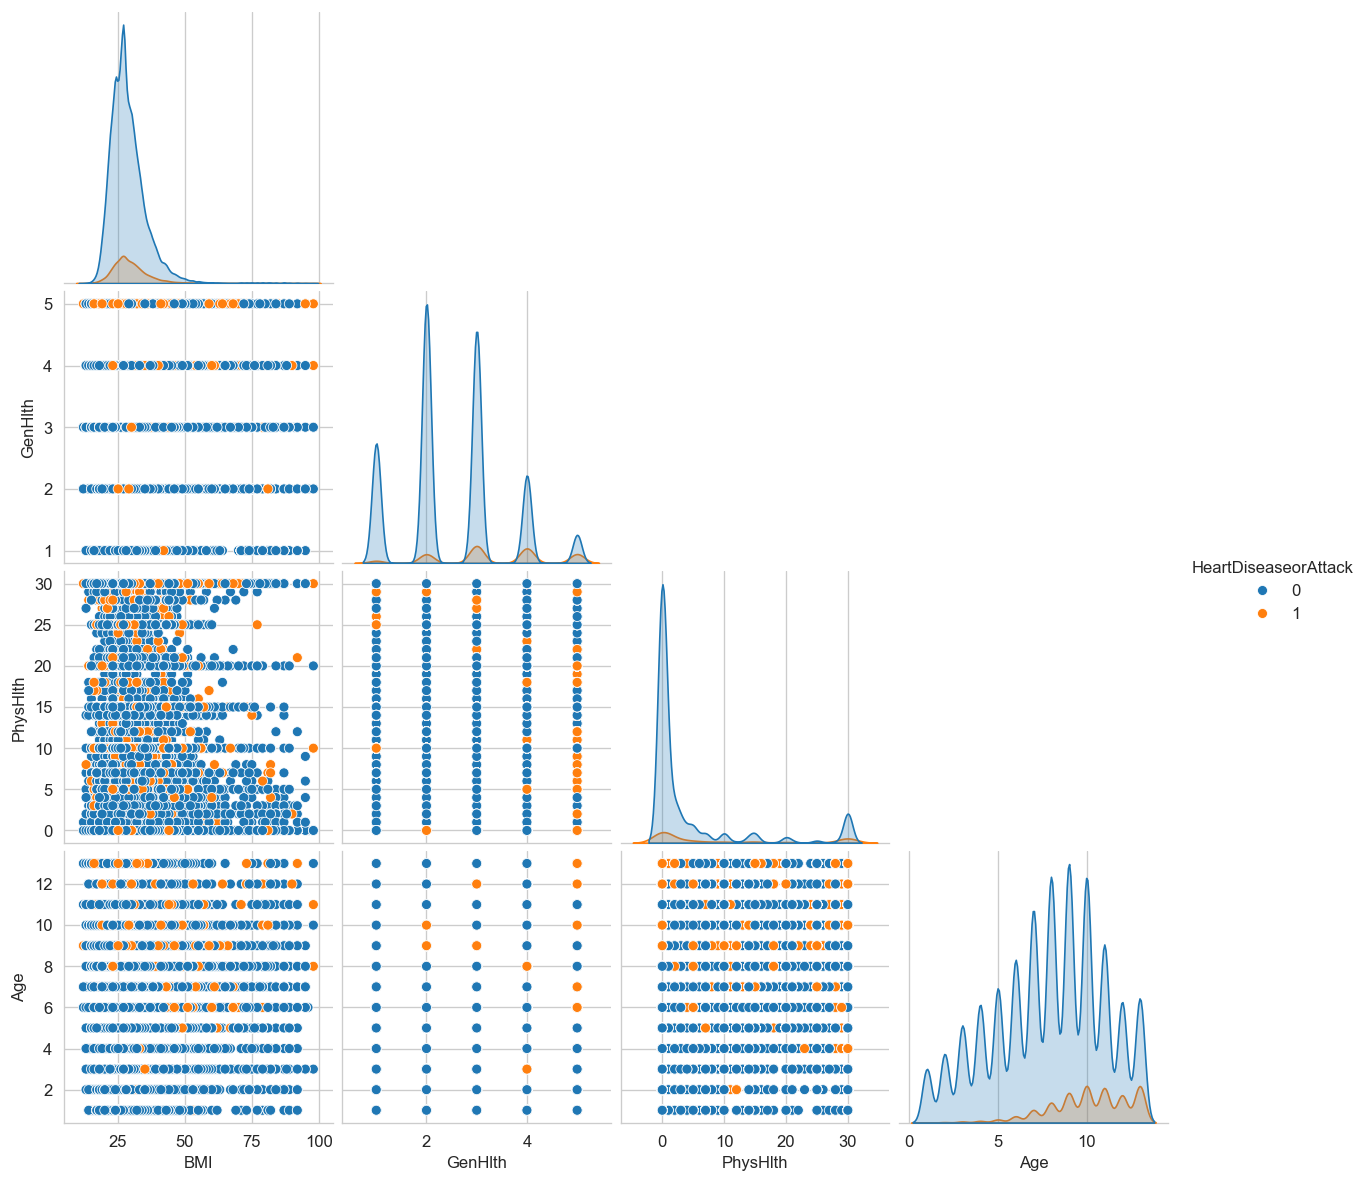

In [16]:
# Use a pairplot on a few important columns to inspect class separation visually.
pairplot_columns = ['HeartDiseaseorAttack', 'BMI', 'GenHlth', 'PhysHlth', 'Age']
pairplot_columns = [col for col in pairplot_columns if col in df.columns]

pairplot = sns.pairplot(df[pairplot_columns], hue='HeartDiseaseorAttack', corner=True)
pairplot.figure.savefig(IMAGE_DIR / 'pairplot_key_features.png', bbox_inches='tight')
plt.show()

In [17]:
# Final note to remind us what to inspect before moving to model training.
print('EDA completed successfully.')
print('All generated plots are saved inside the notebooks/eda_images folder.')
print('Review class imbalance, feature distributions, and target correlations before training models.')

EDA completed successfully.
All generated plots are saved inside the notebooks/eda_images folder.
Review class imbalance, feature distributions, and target correlations before training models.
